     0    1    2    3                4
0  5.1  3.8  1.9  0.4      Iris-setosa
1  4.4  3.2  1.3  0.2      Iris-setosa
2  4.3  3.0  1.1  0.1      Iris-setosa
3  5.8  2.7  4.1  1.0  Iris-versicolor
4  5.7  4.4  1.5  0.4      Iris-setosa


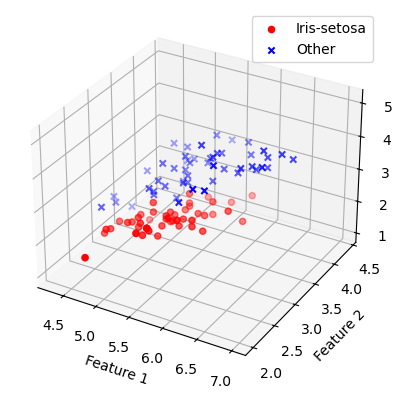

1
Всего ошибок:  -1.0


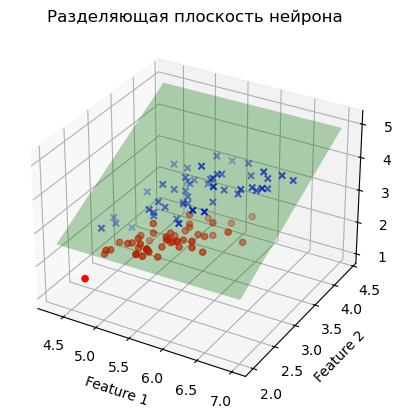

In [1]:
# Попробуем обучить один нейрон на задачу классификации двух классов

import pandas as pd # библиотека pandas нужна для работы с данными
import matplotlib.pyplot as plt # matplotlib для построения графиков
import numpy as np # numpy для работы с векторами и матрицами

# Считываем данные 
# df = pd.read_csv('https://archive.ics.uci.edu/ml/'
#     'machine-learning-databases/iris/iris.data', header=None)

df = pd.read_csv('data.csv')


# смотрим что в них
print(df.head())

# три столбца - это признаки, четвертый - целевая переменная (то, что мы хотим предсказывать)

# выделим целевую переменную в отдельную переменную
y = df.iloc[:, 4].values

# так как ответы у нас строки - нужно перейти к численным значениям
y = np.where(y == "Iris-setosa", 1, -1)

# возьмем два признака, чтобы было удобне визуализировать задачу
X = df.iloc[:, [0, 1, 2]].values

# Признаки в X, ответы в y - постмотрим на плоскости как выглядит задача
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[y==1, 0], X[y==1, 1], X[y==1, 2], color='red', marker='o', label='Iris-setosa')
ax.scatter(X[y==-1, 0], X[y==-1, 1], X[y==-1, 2], color='blue', marker='x', label='Other')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.legend()
plt.show()

# переходим к созданию нейрона
# функция нейрона:
# значение = w1*x1 + w2*x2 + w3*x3 + w0
# ответ = 1, если значение > 0
# ответ = -1, если значение < 0

def neuron(w,x):
    s = w[1]*x[0] + w[2]*x[1] + w[3]*x[2] + w[0]
    return 1 if s >= 0 else -1

# проверим как это работает (веса зададим пока произвольно)
w = np.array([0, 0.1, 0.4, 0.2])
print(neuron(w,X[1])) # вывод ответа нейрона для примера с номером 1


# теперь создадим процедуру обучения
# корректировка веса производится по выражению:
# w_new = w_old + eta*x*y

# зададим начальные значения весов
w = np.random.random(4)
eta = 0.01  # скорость обучения
w_iter = [] # пустой список, в него будем добавлять веса, чтобы потом построить график
for xi, target, j in zip(X, y, range(X.shape[0])):
    predict = neuron(w,xi)   
    w[1:] += (eta * (target - predict)) * xi # target - predict - это и есть ошибка
    w[0] += eta * (target - predict)
    # каждую 10ю итерацию будем сохранять набор весов в специальном списке
    if(j%10==0):
        w_iter.append(w.tolist())

# посчитаем ошибки
sum_err = 0
for xi, target in zip(X, y):
    predict = neuron(w,xi) 
    sum_err += (target - predict)/2

print("Всего ошибок: ", sum_err)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Точки
ax.scatter(X[y==1, 0], X[y==1, 1], X[y==1, 2], color='red', marker='o')
ax.scatter(X[y==-1, 0], X[y==-1, 1], X[y==-1, 2], color='blue', marker='x')
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
x3_grid = -(w[1]*x1_grid + w[2]*x2_grid + w[0]) / w[3]

ax.plot_surface(x1_grid, x2_grid, x3_grid, alpha=0.3, color='green')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title("Разделяющая плоскость нейрона")
plt.show()